# Demo Notebook: Animal Face Classification Inference

This notebook serves as the final project demo, showcasing the core capability of the Deep Learning model pipeline: **classifying animal faces** into one of three categories: `cat`, `dog`, or `wild`.

### Project Goal (Premise)
The primary objective of this project was to implement a robust classification system using transfer learning and to compare the performance of different modeling strategies, specifically focusing on **ensemble methods**.

### Three Modeling Strategies Explored
This demonstration will run inference using the three major model categories we trained:
1.  **Single Model:** A standard, fine-tuned **ResNet50** model as a baseline.
2.  **Homogeneous Ensemble:** An ensemble of **three identical ResNet50** models. The premise is that combining predictions from multiple, independently trained versions of the same architecture can reduce prediction variance and increase robustness.
3.  **Heterogeneous Ensemble:** An ensemble combining **ResNet50, EfficientNetB0, and MobileNetV2**. The premise here is to leverage the unique feature extraction capabilities of structurally different architectures to achieve a more generalized and highly accurate prediction.

The entire process, from data acquisition to model loading, is managed using **Weights & Biases (W&B)** to ensure complete reproducibility and version control.

## Dataset Overview: Animal Faces Dataset

### The Dataset (Premise)
The models were trained on the **Animal Faces Dataset** from Kaggle, which provides high-quality images of animal faces. The dataset is structured for a 3-class classification problem:
- `cat`
- `dog`
- `wild` (e.g., tiger, lion, bear, etc.)

The models are expected to output a probability distribution over these three classes.

### Tool Explanation: Weights & Biases (W&B) (Tie-in)
**Weights & Biases (W&B)** was used extensively for this project.
- **Why W&B?** W&B acts as the central hub for experiment tracking and **artifact management**.
- **The Tie-in:** The original raw dataset and all of the pre-trained model checkpoint weights are stored as W&B Artifacts. This notebook leverages the W&B API to **download the exact dataset and model versions** used in the final training runs, ensuring that the demonstration is running with the correct, verified assets.

## 1. Setup and Configuration

First the global configuration constants are necessary for running inference.
- **IMG_HEIGHT/IMG_WIDTH (128x128):** This size was chosen as a balance between preserving image detail and computational efficiency, and it matches the input requirements for the pre-trained backbone models (like MobileNetV2 and ResNet50) after fine-tuning.
- **ENTITY/PROJECT:** These define the specific W&B location where the dataset and models are stored.
- **MODEL_NAMES:** A curated list of the run IDs used to log the final single model and the ensemble members. This list enables `utils.download_wandb_models_only` to fetch all necessary weights in a single step.


In [ ]:
import wandb
import Weights_and_biases_utils as utils

IMG_HEIGHT, IMG_WIDTH = 128, 128
ENTITY = "pshashid-university-of-maryland"
PROJECT = "animal-faces-classification"

MODEL_NAMES = [
    "run_mobilenetV2_hetero",
    "run_efficientnetb0_hetero",
    "run_resnet50_hetero",
    "run_ResNet50_Homo_3",
    "run_ResNet50_Homo_2",
    "run_ResNet50_Homo_1",
    "run_resnet50"
]

CLASS_INDICES = {'cat': 0, 'dog': 1, 'wild': 2}
RANDOM_STATE = 40

/home/pranavv1/src/venv/client_venv.helpers/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/pranavv1/src/venv/client_venv.helpers/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may

True

## 2. Dataset Handling & W&B Access

W&B is used to access the model and data artifacts and for logging. The `utils.download_dataset()` function automatically pulls the correct version of the Animal Faces dataset from Kaggle via the W&B integration, which is crucial for using the exact images the models were trained and validated on.


In [ ]:
wandb.login()
dataset_path = utils.download_dataset()  # returns cached path if already exists
print("Dataset available at:", dataset_path)

Path to dataset files: /home/pranavv1/.cache/kagglehub/datasets/andrewmvd/animal-faces/versions/1
Dataset available at: /home/pranavv1/.cache/kagglehub/datasets/andrewmvd/animal-faces/versions/1


## 3. Preprocessing and Sample Selection

### Premise
To create a concise demonstration, a randomly chosen sample image for each of the three classes (`cat`, `dog`, `wild`) is selected. This ensures that testing the models across all possible outputs can be done properly.

The images are then loaded and preprocessed by:
1.  Resizing to the required 128x128 dimensions.
2.  Normalizing the pixel values (which is handled internally by `utils.load_and_preprocess`).




In [ ]:
# ----------------------------
# Select Sample Images
# ----------------------------
cat_image_path = utils.get_sample_image_path(dataset_path, 'cat', random_state=RANDOM_STATE)
dog_image_path = utils.get_sample_image_path(dataset_path, 'dog', random_state=RANDOM_STATE)
wild_image_path = utils.get_sample_image_path(dataset_path, 'wild', random_state=RANDOM_STATE)

# ----------------------------
# Load & preprocess images (RGB)
# ----------------------------

cat_array, cat_img = utils.load_and_preprocess(cat_image_path)
dog_array, dog_img = utils.load_and_preprocess(dog_image_path)
wild_array, wild_img = utils.load_and_preprocess(wild_image_path)

images_dict = {
    'cat': (cat_array, cat_img),
    'dog': (dog_array, dog_img),
    'wild': (wild_array, wild_img)
}

## 4. Model Loading

All seven pre-trained model artifacts are now downloaded from W&B and load them into memory. They are organized into three groups for comparison:

| Group Name | Models/Architecture | Type | Inference (Inference) |
| :--- | :--- | :--- | :--- |
| **Single** | `run_resnet50` | ResNet50 | Standard prediction |
| **Homogeneous** | `run_ResNet50_Homo_1`, `2`, `3` | 3× ResNet50 | Average probability from three identical models |
| **Heterogeneous** | `run_mobilenetV2_hetero`, `run_efficientnetb0_hetero`, `run_resnet50_hetero` | MobileNetV2, EfficientNetB0, ResNet50 | Average probability from three diverse models |

The `utils.load_models` function is designed to safely load Keras models from the downloaded artifact directories while ensuring they have the correct input shapes for inference.

In [ ]:
artifact_paths = utils.download_wandb_models_only(MODEL_NAMES, ENTITY, PROJECT)
print("\nAll model artifacts downloaded:")
for name, path in artifact_paths.items():
    print(f"  - {name}: {path}")
    
single_names = ["run_resnet50"]
homo_names = ["run_ResNet50_Homo_1", "run_ResNet50_Homo_2", "run_ResNet50_Homo_3"]
hetero_names = ["run_mobilenetV2_hetero", "run_efficientnetb0_hetero", "run_resnet50_hetero"]

models_single, single_loaded = utils.load_models(single_names, artifact_paths)
models_homo, homo_loaded = utils.load_models(homo_names, artifact_paths)
models_hetero, hetero_loaded = utils.load_models(hetero_names, artifact_paths)



Fetching latest artifact: pshashid-university-of-maryland/animal-faces-classification/run_mobilenetV2_hetero:latest


wandb:   1 of 1 files downloaded.  


Downloaded run_mobilenetV2_hetero to models/run_mobilenetV2_hetero

Fetching latest artifact: pshashid-university-of-maryland/animal-faces-classification/run_efficientnetb0_hetero:latest


wandb:   1 of 1 files downloaded.  


Downloaded run_efficientnetb0_hetero to models/run_efficientnetb0_hetero

Fetching latest artifact: pshashid-university-of-maryland/animal-faces-classification/run_resnet50_hetero:latest


...

Downloaded run_ResNet50_Homo_2 to models/run_ResNet50_Homo_2

Fetching latest artifact: pshashid-university-of-maryland/animal-faces-classification/run_ResNet50_Homo_1:latest


wandb: Downloading large artifact 'run_ResNet50_Homo_1:latest', 220.04MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.4 (615.0MB/s)


Downloaded run_ResNet50_Homo_1 to models/run_ResNet50_Homo_1

Fetching latest artifact: pshashid-university-of-maryland/animal-faces-classification/run_resnet50:latest


wandb: Downloading large artifact 'run_resnet50:latest', 158.83MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.4 (405.7MB/s)


Downloaded run_resnet50 to models/run_resnet50

All model artifacts downloaded:
  - run_mobilenetV2_hetero: models/run_mobilenetV2_hetero
  - run_efficientnetb0_hetero: models/run_efficientnetb0_hetero
  - run_resnet50_hetero: models/run_resnet50_hetero
  - run_ResNet50_Homo_3: models/run_ResNet50_Homo_3
  - run_ResNet50_Homo_2: models/run_ResNet50_Homo_2
  - run_ResNet50_Homo_1: models/run_ResNet50_Homo_1
  - run_resnet50: models/run_resnet50


## 5. Inference

The final step is to run the inference functions provided in `Weights_and_biases_utils.py`. The `Weights_and_biases_utils.run_inference_group` function executes the following steps for each group:
1.  Run the pre-processed sample images through all loaded models in the group.
2.  **For Single Models:** Reports the model's prediction and confidence score.
3.  **For Ensembles:** Calculates the final prediction by averaging the probability vectors across all constituent models (**soft-voting**). This averaging step is the core of how the ensemble prediction is generated (the inference).

The output will clearly demonstrate how each strategy classifies the Cat, Dog, and Wild animal samples.

2025-12-11 12:04:52.296735: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


[ERROR] Failed loading models/run_efficientnetb0_hetero/model_checkpoint.keras: Input 0 of layer "stem_conv" is incompatible with the layer: expected axis -1 of input shape to have value 3, but received input with shape (None, 129, 129, 1)

 Running Inference for Single ResNet50

--- Single ResNet50: Predictions for CAT ---


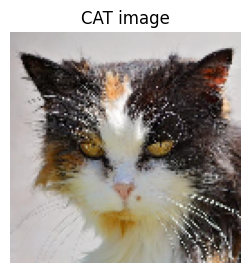

2025-12-11 12:05:01.577849: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fb20c00ef60 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2025-12-11 12:05:01.577867: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
2025-12-11 12:05:01.652067: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


run_resnet50                   → cat (probs=[9.9407011e-01 5.8694398e-03 6.0377406e-05])

[ENSEMBLE Single ResNet50] → cat (avg_probs=[9.9407011e-01 5.8694398e-03 6.0377406e-05])

--- Single ResNet50: Predictions for DOG ---


I0000 00:00:1765472702.456481   46060 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


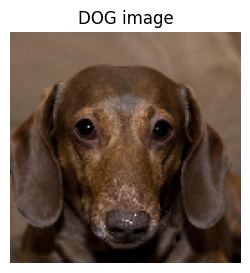

run_resnet50                   → dog (probs=[6.5406683e-05 9.9885595e-01 1.0786048e-03])

[ENSEMBLE Single ResNet50] → dog (avg_probs=[6.5406683e-05 9.9885595e-01 1.0786048e-03])

--- Single ResNet50: Predictions for WILD ---


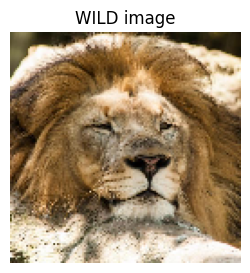

run_resnet50                   → wild (probs=[0.0017224  0.28635162 0.711926  ])

[ENSEMBLE Single ResNet50] → wild (avg_probs=[0.0017224  0.28635162 0.711926  ])

 Running Inference for Homogeneous Ensemble (3× ResNet50)

--- Homogeneous Ensemble (3× ResNet50): Predictions for CAT ---


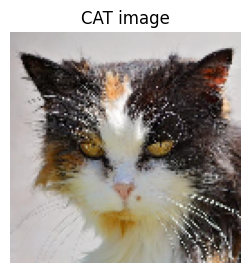

run_ResNet50_Homo_1            → cat (probs=[9.9989641e-01 1.0283644e-04 7.7341116e-07])
run_ResNet50_Homo_2            → cat (probs=[9.9998951e-01 1.0409570e-05 1.2951594e-07])
run_ResNet50_Homo_3            → cat (probs=[9.9999762e-01 1.8888703e-06 5.0768881e-07])

[ENSEMBLE Homogeneous Ensemble (3× ResNet50)] → cat (avg_probs=[9.9996120e-01 3.8378294e-05 4.7020532e-07])

--- Homogeneous Ensemble (3× ResNet50): Predictions for DOG ---


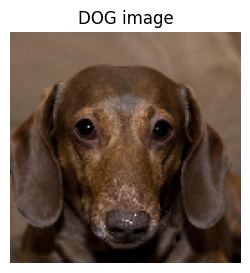

run_ResNet50_Homo_1            → dog (probs=[0.00115293 0.9967866  0.00206044])
run_ResNet50_Homo_2            → dog (probs=[0.01341359 0.9611855  0.02540093])
run_ResNet50_Homo_3            → dog (probs=[9.9808740e-06 9.9989057e-01 9.9390476e-05])

[ENSEMBLE Homogeneous Ensemble (3× ResNet50)] → dog (avg_probs=[0.00485883 0.9859542  0.00918692])

--- Homogeneous Ensemble (3× ResNet50): Predictions for WILD ---


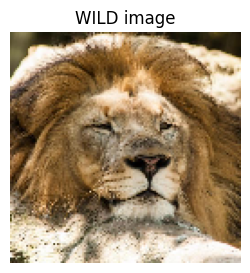

run_ResNet50_Homo_1            → wild (probs=[4.3281153e-04 3.0871215e-03 9.9648005e-01])
run_ResNet50_Homo_2            → wild (probs=[2.6227552e-05 6.7329250e-04 9.9930048e-01])
run_ResNet50_Homo_3            → wild (probs=[0.00567098 0.01580745 0.9785216 ])

[ENSEMBLE Homogeneous Ensemble (3× ResNet50)] → wild (avg_probs=[0.00204334 0.00652262 0.99143404])

 Running Inference for Heterogeneous Ensemble (RN50 + EffNet + MobileNetV2)

--- Heterogeneous Ensemble (RN50 + EffNet + MobileNetV2): Predictions for CAT ---


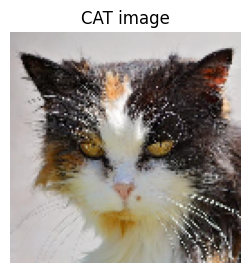

run_mobilenetV2_hetero         → cat (probs=[9.9985754e-01 1.2744954e-04 1.5012508e-05])
run_resnet50_hetero            → cat (probs=[9.9996138e-01 3.7371843e-05 1.2312726e-06])

[ENSEMBLE Heterogeneous Ensemble (RN50 + EffNet + MobileNetV2)] → cat (avg_probs=[9.9990946e-01 8.2410697e-05 8.1218905e-06])

--- Heterogeneous Ensemble (RN50 + EffNet + MobileNetV2): Predictions for DOG ---


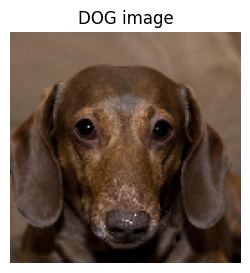

run_mobilenetV2_hetero         → dog (probs=[2.5938571e-04 9.9937183e-01 3.6878447e-04])
run_resnet50_hetero            → dog (probs=[0.00226202 0.9904022  0.00733579])

[ENSEMBLE Heterogeneous Ensemble (RN50 + EffNet + MobileNetV2)] → dog (avg_probs=[0.0012607  0.994887   0.00385229])

--- Heterogeneous Ensemble (RN50 + EffNet + MobileNetV2): Predictions for WILD ---


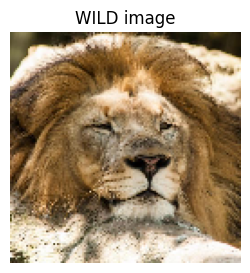

run_mobilenetV2_hetero         → wild (probs=[2.1955206e-05 2.5758441e-04 9.9972051e-01])
run_resnet50_hetero            → wild (probs=[1.4773126e-03 7.9761649e-04 9.9772507e-01])

[ENSEMBLE Heterogeneous Ensemble (RN50 + EffNet + MobileNetV2)] → wild (avg_probs=[7.4963394e-04 5.2760047e-04 9.9872279e-01])


In [ ]:

utils.run_inference_group(models_single, single_loaded, images_dict, "Single ResNet50")
utils.run_inference_group(models_homo, homo_loaded, images_dict, "Homogeneous Ensemble (3× ResNet50)")
utils.run_inference_group(models_hetero, hetero_loaded, images_dict, "Heterogeneous Ensemble (RN50 + EffNet + MobileNetV2)")